# US Accidents (2016–2023): Exploratory Data Analysis

**Question:** What weather, time-of-day and road features best predict whether an accident will be severe, so that authorities can target warnings and resources where they matter most?

**Target:** `severity` (1–4) — the accident's effect on traffic, measured as delay.

## 1. Setup and load

In [1]:
import kagglehub
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")
print('path to dataset files:', path)

c:\Users\jagmeet\vsc\pypharm_eda\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


path to dataset files: C:\Users\jagmeet\.cache\kagglehub\datasets\sobhanmoosavi\us-accidents\versions\13


In [ ]:
import pandas as pd 
import numpy as np 
import statistics as stats
import seaborn as sns 
import matplotlib.pyplot as plt
import math

In [ ]:
df = pd.read_csv(path + '/US_Accidents_March23.csv')

### Structure and memory

- Inspect data types and non-null counts.
- Split the columns into numerical and categorical lists.

In [ ]:
df.dtypes
df.info(show_counts=True)
num_cols = df.select_dtypes(include = 'number').columns.tolist()
cat_cols = df.select_dtypes(exclude= 'number').columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   ID                     7728394 non-null  str    
 1   Source                 7728394 non-null  str    
 2   Severity               7728394 non-null  int64  
 3   Start_Time             7728394 non-null  str    
 4   End_Time               7728394 non-null  str    
 5   Start_Lat              7728394 non-null  float64
 6   Start_Lng              7728394 non-null  float64
 7   End_Lat                4325632 non-null  float64
 8   End_Lng                4325632 non-null  float64
 9   Distance(mi)           7728394 non-null  float64
 10  Description            7728389 non-null  str    
 11  Street                 7717525 non-null  str    
 12  City                   7728141 non-null  str    
 13  County                 7728394 non-null  str    
 14  State                  772839

- Check how the rows are indexed.
- **Finding:** RangeIndex — a simple row counter, no meaningful index.

In [ ]:
df.index

RangeIndex(start=0, stop=7728394, step=1)

- Compare shallow vs deep memory usage to see how much is hidden in object (string) columns.
- **Finding:** ~78.9% of memory is hidden in object columns.

In [ ]:
shallow_memory = df.memory_usage(deep = False).sum()
deep_memory = df.memory_usage(deep = True).sum()
hidden = deep_memory - shallow_memory
pct_hidden = hidden / deep_memory * 100

## 2. Numerical features

Describe each column: central tendency, spread, range and shape (skew).

### Summary statistics

- Summary statistics for the numerical columns only.

In [ ]:
df.describe(include = 'number')

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


**Findings**
- Compare the 50%, 75% and max values.
- Distance, temperature, wind chill, visibility, wind speed and precipitation show a large gap between 75% and max — potential outliers.
- The mean hasn't been pulled far from the median — the extreme values are a small minority in a very large dataset.
- To check: whether the volume of data masks the outliers (the top 0.01% of 7.7m rows is ~770 rows).

### Boxplots

View the outliers visually on a 100k random sample.

- Draw a 100k random sample (fixed seed) for plotting.
- Boxplots of every numerical column in a grid, 4 plots per row.
- x-axis labels removed — the title already names the column.

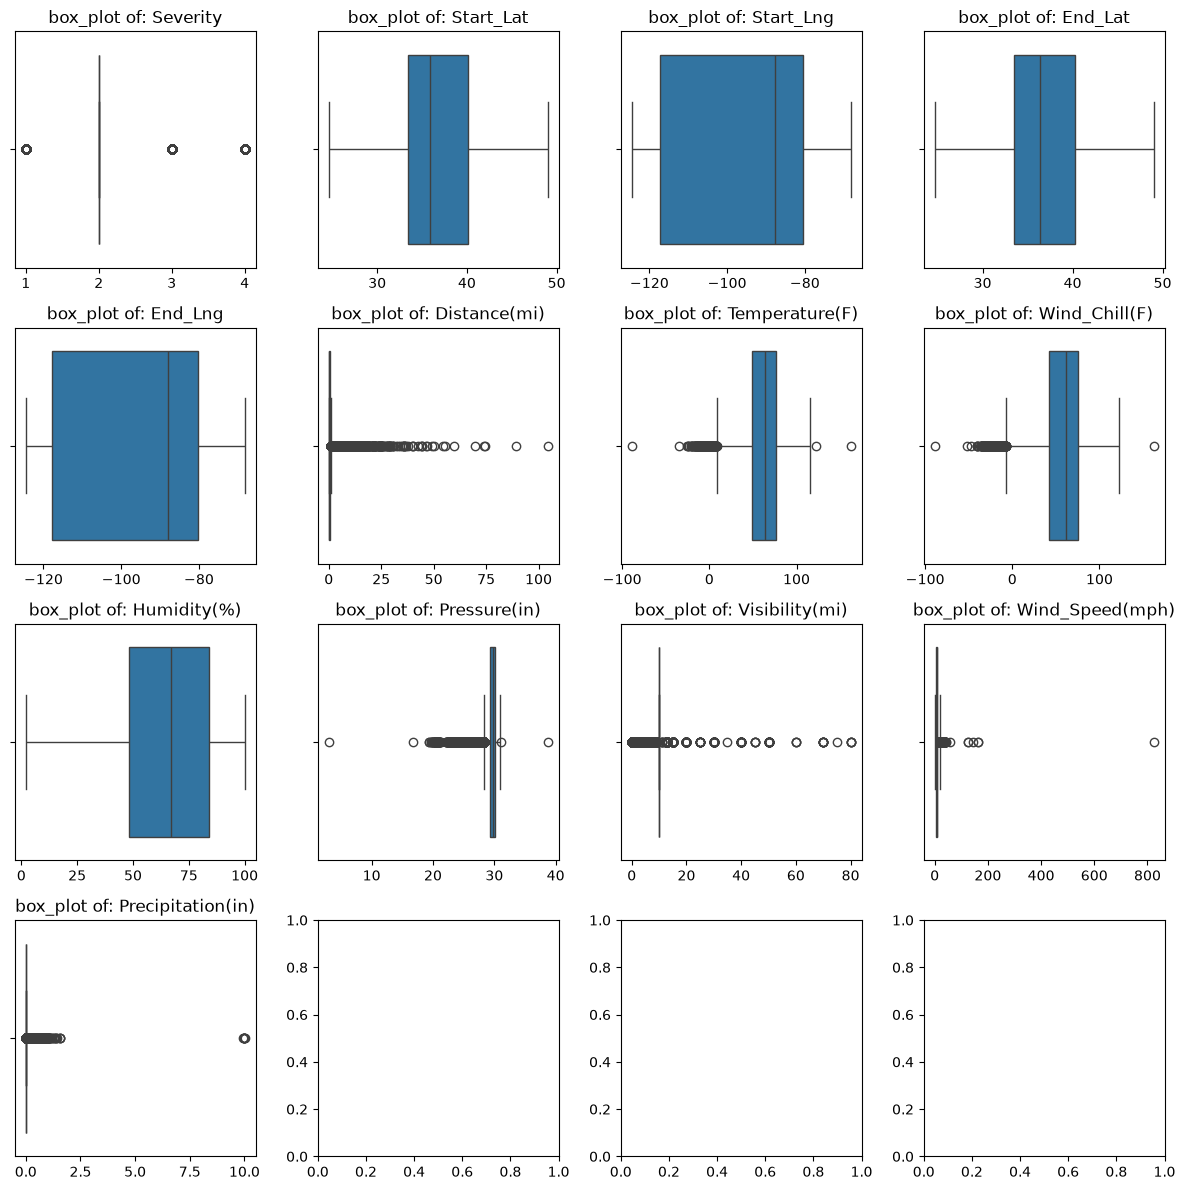

In [ ]:
sample_size = 100000
sample = df.sample(n = sample_size, random_state = 42)

num_cols_sample1 = sample.select_dtypes(include=[np.number]).columns.tolist()
total_plots = len(num_cols_sample1)
col_wrap = 4

num_rows = math.ceil(total_plots/col_wrap)

fig, axes = plt.subplots(
    nrows=num_rows, ncols=col_wrap, figsize=(12, num_rows * 3), sharex=False
)
axes = axes.flatten()
for i, col_name in enumerate(num_cols_sample1):
    sns.boxplot(data=sample, x=col_name, ax=axes[i])
    axes[i].set_title(f'box_plot of: {col_name}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

**How to read a boxplot**
- A box sitting hard against one whisker means skew.
- A box collapsed to a line means one value dominates.

**Findings**
- **Severity** — dominated by class 2; the other classes are much rarer.
- **Wind_Speed(mph)** — a point at ~820, likely an error or unit mix-up.
- **Temperature(F)** — points at −90 and 160; +160°F is impossible.
- **Wind_Chill(F)** — derived from temperature; the same outliers appear.
- **Pressure(in)** — values down to 2–3. Sea level is ~29.9 and Denver ~24; below ~15 is impossible.
- **Precipitation(in)** — over 75% of values are 0, plus some outliers. Consider a binary feature (precipitation > 5 = 1, else 0).
- **Visibility(mi)** — most values sit at exactly 10; the outliers suggest 10 may be a placeholder — to check.

### Histograms

A histogram shows the shape of a column: where most values sit, how many rows land in each bin, how many peaks there are, and how far out the tails reach.

- Histograms of every numerical column on the same sample, 100 bins.
- x-axis labels removed — the title already names the column.

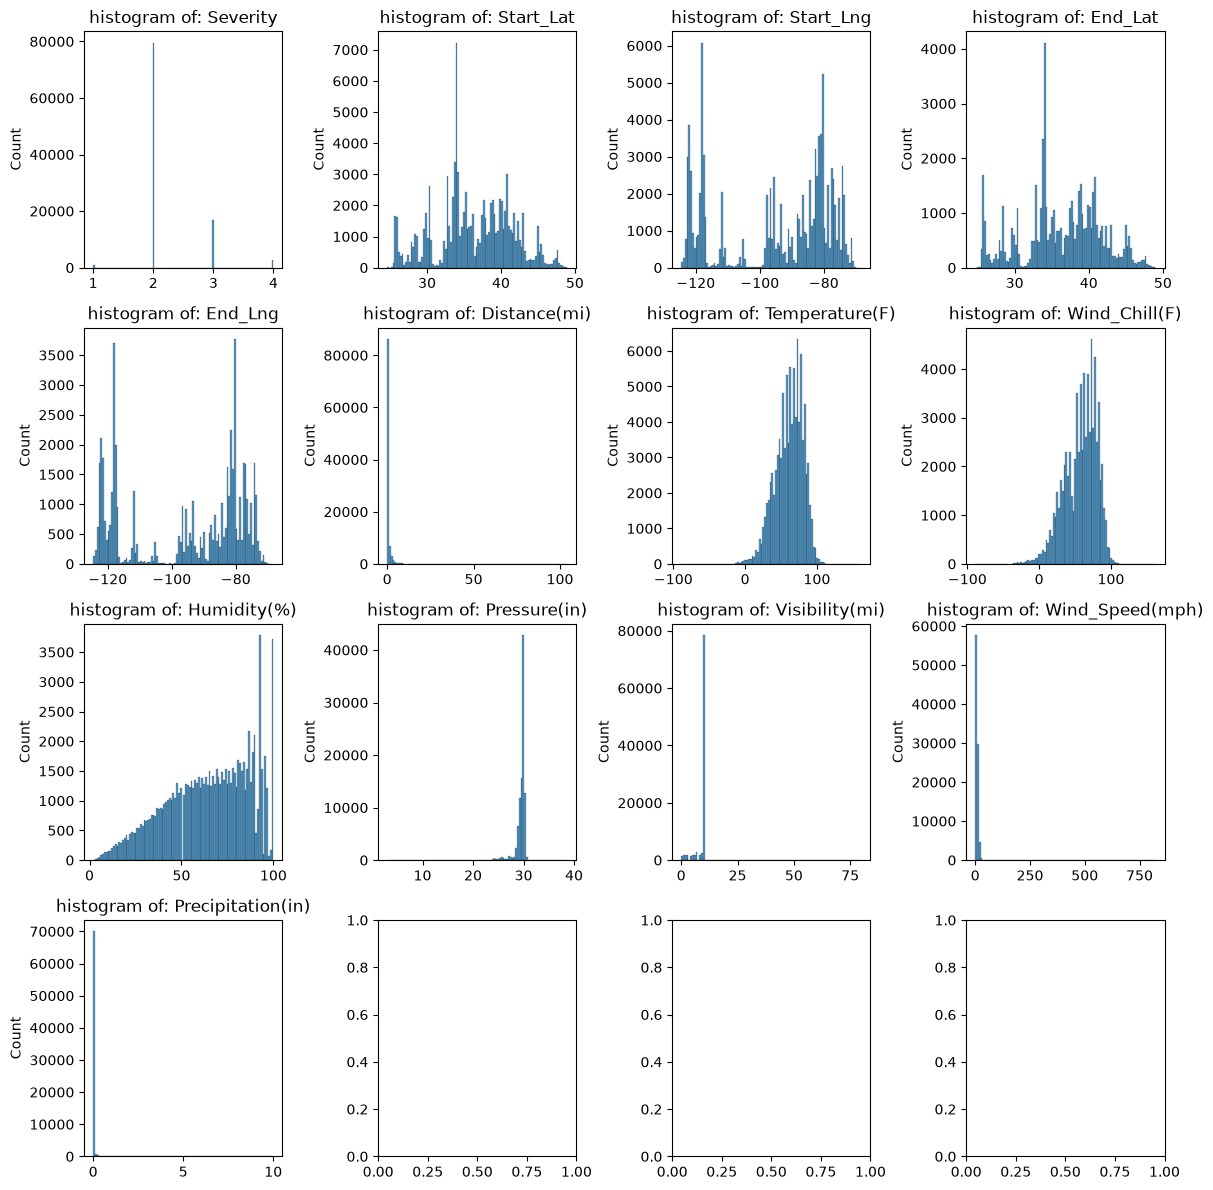

In [ ]:
fig, axes = plt.subplots(
    nrows=num_rows, ncols=col_wrap, figsize=(12, num_rows * 3), sharex=False
)
axes = axes.flatten()
for i, col_name in enumerate(num_cols_sample1):
    sns.histplot(data=sample, x=col_name, ax=axes[i], bins = 100)
    axes[i].set_title(f'histogram of: {col_name}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

**Findings** (100 bins)

- **Severity** — 4 discrete categories, dominated by 2. Ordinal, not continuous; bar chart is the correct plot.
- **Start_Lat / End_Lat** — multi-peaked, main cluster ~33–34. Reflects population density, not a data problem.
- **Start_Lng / End_Lng** — two clear peaks at ~−120 (West Coast) and ~−80 (East Coast); sparse interior. Data is heavily coastal/urban.
- **Distance(mi)** — extreme spike at 0, long right tail. This is length of road affected, not distance travelled. **Leakage: known only after the incident — exclude as a predictor.**
- **Temperature(F)** — peak ~65–70, tail to the left. Mildly **left-skewed**. Impossible values (−90, 160) seen in the boxplot are invisible here — too few rows to register.
- **Wind_Chill(F)** — same shape as temperature, derived from it. Inherits the same impossible values.
- **Humidity(%)** — mass at 90–100, thin tail down to 0. **Left-skewed** (tail on the left, not right).
- **Pressure(in)** — tight peak at ~29.9 with a left tail. Values below ~15 are physically impossible.
- **Visibility(mi)** — hard spike at 10. Not a placeholder: airport reports **cap** visibility at 10 miles, so the column is censored. Values above 10 need separate investigation.
- **Wind_Speed(mph)** — concentrated near 0 (calm). Check whether exact zeros are unusually frequent — may be "not recorded" in disguise.
- **Precipitation(in)** — >75% exactly 0 (no rain). Genuine zeros, separate from the 2.2m missing rows. Consider a binary "any precipitation" feature instead of the raw amount.

**Boxplot vs histogram:** boxplots flag individual extreme points; histograms show shape but bury anything rare. Run both

### Extreme percentiles and the mean vs median audit

In [ ]:
df.describe(include = 'number', percentiles = [0.5, 0.75,0.99, 0.9999])

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
99%,4.000000e+00,4.747886e+01,-7.148164e+01,4.727449e+01,-7.285381e+01,6.955000e+00,9.600000e+01,9.600000e+01,1.000000e+02,3.044000e+01,1.000000e+01,2.300000e+01,1.800000e-01
99.99%,4.000000e+00,4.887415e+01,-6.982946e+01,4.888346e+01,-6.962346e+01,4.918000e+01,1.110000e+02,1.110000e+02,1.000000e+02,3.082000e+01,7.000000e+01,4.300000e+01,2.545193e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


**Findings**
- Temperature, wind chill, pressure, visibility, wind speed and precipitation: a large jump between the 99.99th percentile and the max — outliers.
- Distance: both the 99.99th percentile and the max are extreme relative to the mean and median — the mean isn't safe to use.

- Define `audit_cols`: decide for each numerical column whether the mean is safe or the median should be used.
- For each column, calculate the median, 75th and 99.99th percentiles, plus mean, std and max.
- Check 1 — mean above the 75th percentile (already above the median) suggests outliers are pulling it.
- Check 2 — ratio of max to the 99.99th percentile: a large gap indicates an extreme tail.
- Check 3 — ratio of mean to median.
- Return a verdict and the reasons for each column.

In [ ]:
def audit_cols(df):
    result=[]
    num_cols = df.select_dtypes(include = [np.number]).columns
    for col in num_cols:
        median, p75, p99_99 = df[col].quantile([0.5, 0.75, 0.9999])
        mean, std, max = df[col].agg(['mean', 'std', 'max'])

        mean_greater_than_75 = mean > p75
        if p99_99>0:
            ratio = max / p99_99
        else:
            ratio = max if max > 0 else 1
        if median > 0:
            median_ratio = mean / median
        else:
            median_ratio = mean if mean > 0 else 1

        if mean_greater_than_75 or ratio > 1.2 and ratio > 3:
            verdict = 'median must be used , mean is likely biased'
            reason = []
            if mean_greater_than_75: reason.append('mean is greater than 75%')
            if median_ratio > 1.2: reason.append(f"Mean is {median_ratio:.1f}x higher than Median")
            if ratio > 3: reason.append(f'max is {ratio:.1f}x higher than 99.99% percentile (Extreme Tail)')
            reason_str = ", ".join(reason)
        else:
            verdict = "Use MEAN (Safe)"
            reason_str = "Data is balanced and symmetric"
        result.append({'column': col, 'mean': mean, 'median': median, 'std': std, 'max': max, 'p75': p75, 'p99_99': p99_99, 'mean_greater_than_75': mean_greater_than_75, 'ratio_max_to_p99_99': ratio, 'median_ratio': median_ratio, 'verdict': verdict, 'reason': reason_str})
    return pd.DataFrame(result)

In [ ]:
audit_report = audit_cols(df)
print(audit_report.to_string(index = False))

           column       mean     median       std         max        p75     p99_99  mean_greater_than_75  ratio_max_to_p99_99  median_ratio                                     verdict                                                                                                               reason
         Severity   2.212384   2.000000  0.487531    4.000000   2.000000   4.000000                  True             1.000000      1.106192 median must be used , mean is likely biased                                                                                             mean is greater than 75%
        Start_Lat  36.201195  35.823974  5.076079   49.002201  40.084959  48.874151                 False             1.002620      1.010530                             Use MEAN (Safe)                                                                                       Data is balanced and symmetric
        Start_Lng -94.702545 -87.766616 17.391756  -67.113167 -80.353676 -69.829456           

- Split the audit report into columns where the mean is safe and columns where the median should be used.
- Next: inspect the median columns further for anomalies.

In [ ]:
mean_cols = audit_report[audit_report.iloc[:, -1] == "Data is balanced and symmetric"]
median_cols = audit_report[audit_report.iloc[:, -1] != "Data is balanced and symmetric"]

### Skew and kurtosis

These show *why* the mean is unsafe for particular columns. Values rounded to 2 decimal places.
- **Skew** — how asymmetric the column is.
- **Kurtosis** — how heavy the tails are: how often extreme values occur and how far out they sit.
  - 0 — normal
  - above 0 — heavy tails
  - below 0 — flat, light tails

In [ ]:
round(df.select_dtypes(include = 'number').skew(), 2)
round(df.select_dtypes(include = 'number').kurtosis(), 2)

Severity                 3.30
Start_Lat               -0.53
Start_Lng               -1.36
End_Lat                 -0.56
End_Lng                 -1.56
Distance(mi)          1649.60
Temperature(F)          -0.00
Wind_Chill(F)            0.15
Humidity(%)             -0.72
Pressure(in)            21.84
Visibility(mi)          81.89
Wind_Speed(mph)       1085.48
Precipitation(in)    10710.92
dtype: float64

## 3. Categorical features

- Build the list of categorical columns.
- Count missing values in each categorical column.

In [ ]:
cat_cols = df.select_dtypes(exclude = [np.number]).columns.tolist()
df.loc[:, cat_cols].isna().sum()

ID                            0
Source                        0
Start_Time                    0
End_Time                      0
Description                   5
Street                    10869
City                        253
County                        0
State                         0
Zipcode                    1915
Country                       0
Timezone                   7808
Airport_Code              22635
Weather_Timestamp        120228
Wind_Direction           175206
Weather_Condition        173459
Amenity                       0
Bump                          0
Crossing                      0
Give_Way                      0
Junction                      0
No_Exit                       0
Railway                       0
Roundabout                    0
Station                       0
Stop                          0
Traffic_Calming               0
Traffic_Signal                0
Turning_Loop                  0
Sunrise_Sunset            23246
Civil_Twilight            23246
Nautical

- Count unique values in each categorical column.
- Convert all column names to lower case for consistency.

In [ ]:
df.loc[:, cat_cols].nunique()
df.columns = df.columns.str.lower()

### `source`

- `source`: unique values and their proportions, including NaN.
- **Finding:** 3 categories — convert to `category` dtype to save memory.

In [ ]:
df.source.unique()
df.source.value_counts(normalize = True, dropna = False)
df.source = df.source.astype('category')

### `country`

- `country`: check its values.
- **Finding:** every row is USA — no information. Drop the column.

In [ ]:
df.country.value_counts(normalize = True, dropna = False)
df.drop(columns = ['country'], inplace = True)

- Rebuild the categorical column list after dropping `country`, and recount unique values.

In [ ]:
cat_cols_1 = df.select_dtypes(exclude = [np.number]).columns.tolist()
df.loc[:, cat_cols_1].nunique() 

id                       7728394
source                         3
start_time               6131796
end_time                 6705355
description              3761578
street                    336306
city                       13678
county                      1871
state                         49
zipcode                   825094
timezone                       4
airport_code                2045
weather_timestamp         941331
wind_direction                24
weather_condition            144
amenity                        2
bump                           2
crossing                       2
give_way                       2
junction                       2
no_exit                        2
railway                        2
roundabout                     2
station                        2
stop                           2
traffic_calming                2
traffic_signal                 2
turning_loop                   1
sunrise_sunset                 2
civil_twilight                 2
nautical_t

### `wind_direction`

- `wind_direction`: proportions and counts.
- **Finding:** duplicates caused by inconsistent naming (e.g. North vs N, CALM vs calm).
- Valid directions: N, E, S, W, NE, NW, SE, SW, NNE, ENE, ESE, SSE, SSW, WSW, WNW, NNW.
- Replace full words with abbreviations, fill NaN with 'NA', convert to `category`.
- Convert all values to upper case for consistency.

In [ ]:
df.wind_direction.value_counts(normalize = True, dropna = False)
df.wind_direction.value_counts()

df.wind_direction = df.wind_direction.replace({'North': 'N',
                                               'East': 'E',
                                               'South': 'S',
                                               'West': 'W',
                                               'CALM': 'calm',
                                               'Variable': 'variable'}, regex = True).fillna('NA').astype('category')

df.wind_direction = df.wind_direction.str.upper()

- Check `wind_direction` proportions after cleaning.
- **Finding:** 2.26% of values are NA — note for later.

In [ ]:
df.wind_direction.value_counts(normalize = True, dropna = False)*100

wind_direction
CALM        17.211610
S            7.729471
W            7.099327
N            5.959013
SSW          4.979560
E            4.948751
WNW          4.901161
NW           4.779156
SW           4.715986
WSW          4.578002
SSE          4.517239
NNW          4.314312
SE           3.815812
ESE          3.471756
NE           3.346607
ENE          3.344472
NNE          3.303545
VAR          3.242148
NA           2.267043
VARIABLE     1.475028
Name: proportion, dtype: float64

### `timezone`

- `timezone`: proportions of each value.
- **Finding:** 7 values in 'US/...' format.
- Map to short lower-case names, fill NaN with 'NA', convert to `category`.

In [ ]:
df.timezone.value_counts(normalize = True, dropna = False)
df.timezone = df.timezone.replace({'US/Eastern': 'eastern',
                                   'US/Central': 'central',
                                   'US/Mountain': 'mountain',
                                   'US/Pacific': 'pacific',
                                   'UTC': 'utc'}, regex = True).fillna('NA').astype('category')

In [ ]:
df.timezone.value_counts(normalize = True, dropna = False) 
df.rename(columns = {'timezone': 'timezone(us)'}, inplace = True)

- Rebuild the categorical column list after the renames.

In [ ]:
cat_cols2 = df.select_dtypes(exclude = [np.number]).columns.tolist()

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 45 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   id                     str     
 1   source                 category
 2   severity               int64   
 3   start_time             str     
 4   end_time               str     
 5   start_lat              float64 
 6   start_lng              float64 
 7   end_lat                float64 
 8   end_lng                float64 
 9   distance(mi)           float64 
 10  description            str     
 11  street                 str     
 12  city                   str     
 13  county                 str     
 14  state                  str     
 15  zipcode                str     
 16  timezone(us)           category
 17  airport_code           str     
 18  weather_timestamp      str     
 19  temperature(f)         float64 
 20  wind_chill(f)          float64 
 21  humidity(%)            float64 
 22  press

### Road features and light conditions

- Count unique values in the road-feature and light-condition columns (28–46).
- Goal: see whether any can be combined.
- **Finding:** road features are boolean (True/False); light columns are Day/Night.
- Not run: `df.loc[:, cat_cols2].nunique()`, `df.iloc[:, 28:46]`.

In [ ]:
df.iloc[:, 28:46].nunique()

amenity                  2
bump                     2
crossing                 2
give_way                 2
junction                 2
no_exit                  2
railway                  2
roundabout               2
station                  2
stop                     2
traffic_calming          2
traffic_signal           2
turning_loop             1
sunrise_sunset           2
civil_twilight           2
nautical_twilight        2
astronomical_twilight    2
dtype: int64

#### `turning_loop`

- `turning_loop`: check its values.
- **Finding:** 100% False, no missing and no True values. Drop the column.

In [ ]:
df.loc[:, ['turning_loop']].value_counts(normalize = True, dropna = False)*100
df.drop(columns = 'turning_loop', inplace = True)

#### Boolean dtypes

Re-read the dtypes and confirm the road features are boolean.

In [ ]:
cat_cols3 = df.select_dtypes(exclude = [np.number]).columns.tolist()
df.loc[:, cat_cols3].dtypes

id                            str
source                   category
start_time                    str
end_time                      str
description                   str
street                        str
city                          str
county                        str
state                         str
zipcode                       str
timezone(us)             category
airport_code                  str
weather_timestamp             str
wind_direction             object
weather_condition             str
amenity                      bool
bump                         bool
crossing                     bool
give_way                     bool
junction                     bool
no_exit                      bool
railway                      bool
roundabout                   bool
station                      bool
stop                         bool
traffic_calming              bool
traffic_signal               bool
sunrise_sunset                str
civil_twilight                str
nautical_twili

- Select the boolean columns.
- Calculate the True/False percentage for each.

In [ ]:
bool_col = df.select_dtypes(include = ['bool'])

proportion = bool_col.apply(lambda x: x.value_counts(normalize = True)*100)

- Transpose the table for easier reading.
- **Finding:** mostly False — six features are True in under 1% of rows, so estimates for them will be fragile.

In [ ]:
proportion.transpose()

,False,True
amenity,98.753506,1.246494
bump,99.954531,0.045469
crossing,88.694119,11.305881
give_way,99.526655,0.473345
junction,92.607235,7.392765
no_exit,99.747101,0.252899
railway,99.133339,0.866661
roundabout,99.996778,0.003222
station,97.387543,2.612457
stop,97.226190,2.773810


#### Do the light columns agree?

- Crosstab `sunrise_sunset` against `astronomical_twilight` to see how often they agree.
- Diagonal: both columns say the same thing (both Day or both Night).
- Off-diagonal: they disagree. If they often disagree, each adds information; if they rarely do, they're highly correlated and one is redundant.

In [ ]:
pd.crosstab(df.sunrise_sunset, df.astronomical_twilight, normalize = True).round(2)

astronomical_twilight,Day,Night
sunrise_sunset,,
Day,0.69,0.00
Night,0.14,0.17


- Same agreement check for `civil_twilight` against `nautical_twilight`.

In [ ]:
pd.crosstab(df.civil_twilight, df.nautical_twilight, normalize = True).round(2)

nautical_twilight,Day,Night
civil_twilight,,
Day,0.74,0.00
Night,0.05,0.21


**Interpretation**

The four light columns rank by when each considers day to end and night to start: `sunrise_sunset` → `civil_twilight` → `nautical_twilight` → `astronomical_twilight`.

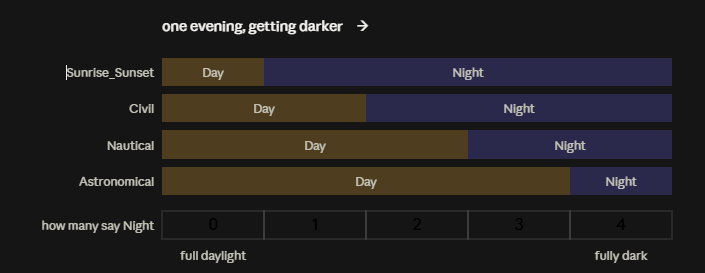

Reading down the bottom row (5 segments): 0 = all four say Day, 1 = one says Night, 2 = two say Night, and so on up to 4.

**Next:** build a column scoring each row from 0 to 4.

## Checkpoint

Save as `df_temp` so the notebook doesn't need a full re-run if the kernel struggles.

In [ ]:
df.to_parquet('../data/df_temp.parquet', index = True)

- Reload imports and the checkpoint from parquet.

In [ ]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
df_temp = pd.read_parquet('../data/df_temp.parquet')

## 4. Weather condition

The last categorical column to profile.

- `weather_condition`: convert to string, lower case, and strip whitespace.
- **Finding:** rows missing weather tend to be missing many other columns too.
- **Finding:** stripping whitespace reduced unique values from 145 to 144.

In [ ]:
df_temp.weather_condition = df_temp.weather_condition.astype('str')
df_temp.weather_condition = df_temp.weather_condition.str.lower()
df_temp[df_temp.weather_condition.isna()]
df_temp.weather_condition = df_temp.weather_condition.str.strip()

In [ ]:
df_temp.weather_condition.nunique()

144

In [ ]:
df_temp.weather_condition.value_counts(normalize= True, dropna = False, ascending = False).cumsum()

weather_condition
fair                         0.331350
mostly cloudy                0.462838
cloudy                       0.568563
clear                        0.673209
partly cloudy                0.763651
                               ...   
heavy sleet / windy          0.999999
sand / windy                 1.000000
heavy rain shower / windy    1.000000
blowing snow nearby          1.000000
drifting snow                1.000000
Name: proportion, Length: 145, dtype: float64

**Findings**
- The top 13 values cover 95% of rows (cumulative proportion) — the rest are mostly variations of them.

**Note for cleaning:** list all values and find the shared underlying conditions; check whether they map onto the top 13.

In [ ]:
df_temp.weather_condition.unique().tolist()

['light rain',
 'overcast',
 'mostly cloudy',
 'rain',
 'light snow',
 'haze',
 'scattered clouds',
 'partly cloudy',
 'clear',
 'snow',
 'light freezing drizzle',
 'light drizzle',
 'fog',
 'shallow fog',
 'heavy rain',
 'light freezing rain',
 'cloudy',
 'drizzle',
 nan,
 'light rain showers',
 'mist',
 'smoke',
 'patches of fog',
 'light freezing fog',
 'light haze',
 'light thunderstorms and rain',
 'thunderstorms and rain',
 'fair',
 'volcanic ash',
 'blowing sand',
 'blowing dust / windy',
 'widespread dust',
 'fair / windy',
 'rain showers',
 'mostly cloudy / windy',
 'light rain / windy',
 'hail',
 'heavy drizzle',
 'showers in the vicinity',
 'thunderstorm',
 'light rain shower',
 'light rain with thunder',
 'partly cloudy / windy',
 'thunder in the vicinity',
 't-storm',
 'heavy thunderstorms and rain',
 'thunder',
 'heavy t-storm',
 'funnel cloud',
 'heavy t-storm / windy',
 'blowing snow',
 'light thunderstorms and snow',
 'heavy snow',
 'low drifting snow',
 'light ice pel

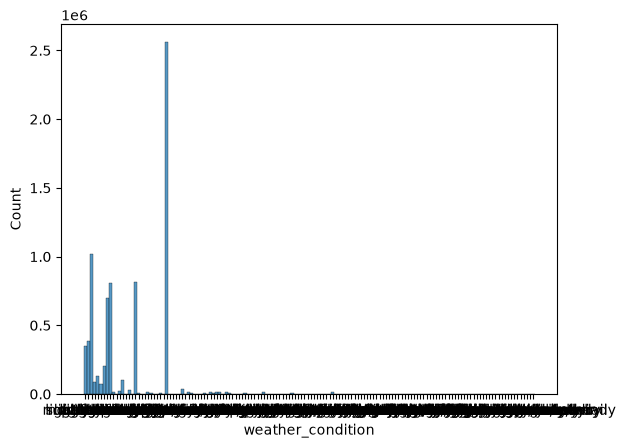

In [ ]:
sns.histplot(x = df_temp.weather_condition, bins = 145)
plt.show()

## 5. Light score

- Define the four light columns and view them.
- **Finding:** 23,246 rows are NaN — to be handled later.

In [ ]:
light_list = ['sunrise_sunset', 'civil_twilight', 'nautical_twilight', 'astronomical_twilight']
df_temp.loc[:, light_list]

,sunrise_sunset,civil_twilight,nautical_twilight,astronomical_twilight
0,Night,Night,Night,Night
1,Night,Night,Night,Day
2,Night,Night,Day,Day
3,Night,Day,Day,Day
4,Day,Day,Day,Day
...,...,...,...,...
7728389,Day,Day,Day,Day
7728390,Day,Day,Day,Day
7728391,Day,Day,Day,Day
7728392,Day,Day,Day,Day


- Encode Day = 0, Night = 1.

In [ ]:
df_temp[light_list] = df_temp[light_list].replace({'Day' :0, 'Night': 1}, regex = False)

- Proportion of Day/Night in each light column.
- Sum the four columns into `light_score` (0–4). `skipna=False` keeps the row NaN if any column is missing.
- **Finding:** `light_score` contains 0, 1, 2, 3, 4 and NaN.

In [ ]:
df_temp[light_list].apply(lambda x: x.value_counts(normalize = True))
df_temp['light_score'] = df_temp[light_list].sum(axis= 1, skipna = False)
df_temp['light_score'].unique()

array([4, 3, 2, 1, 0, nan], dtype=object)

- Proportion of each `light_score` value.
- Crosstab `light_score` against `sunrise_sunset` — any score of 0 should be Day, since `sunrise_sunset` is the least strict column.

In [ ]:
df_temp.light_score.value_counts(normalize= True, dropna= False)

pd.crosstab(df_temp.light_score, df_temp.sunrise_sunset, normalize = True).round(2)

sunrise_sunset,0,1
light_score,,
0,0.69,0.00
1,0.00,0.05
2,0.00,0.05
3,0.00,0.04
4,0.00,0.17


**Interpretation**
- Astronomical twilight is the strictest — the last of the four to switch to Night, so it only says Night when all four do (`light_score` = 4).
- Share of night accidents: 1 − 0.69 = 0.31. Of that 0.31, 0.14 is not astronomical night (true dark).
- So 0.14 / 0.31 ≈ 0.44 — about 44% of night accidents happen during twilight.

### Missing light values

- Check whether the missing light values fall on the same rows, and what else is missing on those rows.
- **Finding:** those rows are also missing precipitation, wind chill, city, end lat/lng, and some wind speed.

In [ ]:
light_data_missing = df_temp[df_temp.loc[:, light_list].isna().any(axis=1)]
light_data_missing.isna().sum()

Unnamed: 0                   0
id                           0
source                       0
severity                     0
start_time                   0
end_time                     0
start_lat                    0
start_lng                    0
end_lat                   1675
end_lng                   1675
distance(mi)                 0
description                  0
street                     177
city                       253
county                       0
state                        0
zipcode                     41
timezone(us)               224
airport_code              2575
weather_timestamp         2744
temperature(f)            2898
wind_chill(f)             3172
humidity(%)               2948
pressure(in)              2862
visibility(mi)            2942
wind_direction            2995
wind_speed(mph)           3010
precipitation(in)         2963
weather_condition         2924
amenity                      0
bump                         0
crossing                     0
give_way

## 6. Time columns

`start_time`, `end_time` and `weather_timestamp` aren't categorical — they should be datetimes.

In [ ]:
df_temp.start_time

0          2016-02-08 05:46:00
1          2016-02-08 06:07:59
2          2016-02-08 06:49:27
3          2016-02-08 07:23:34
4          2016-02-08 07:39:07
                  ...         
7728389    2019-08-23 18:03:25
7728390    2019-08-23 19:11:30
7728391    2019-08-23 19:00:21
7728392    2019-08-23 19:00:21
7728393    2019-08-23 18:52:06
Name: start_time, Length: 7728394, dtype: str

- `start_time`, `end_time` and `weather_timestamp` are stored as strings.
- Convert to datetime. Still to do: align across time zones.

In [ ]:
df_temp.start_time.dtype
df_temp.end_time.dtype
df_temp['start_time'] = pd.to_datetime(df_temp['start_time'], format="ISO8601")
df_temp['end_time'] = pd.to_datetime(df_temp['end_time'], format="ISO8601")
df_temp['weather_timestamp'] = pd.to_datetime(df_temp['weather_timestamp'], format="ISO8601")

### Duration

- Calculate accident duration (`time_delta`) as end minus start, in seconds.
- Summary statistics, skew and kurtosis of the duration.
- **Finding:** very high kurtosis — extreme values sit far out in the tail.

In [ ]:
df_temp['time_delta'] = df_temp.end_time - df_temp.start_time
df_temp['time_delta'] = df_temp['time_delta'].dt.total_seconds()

df_temp['time_delta'].describe(percentiles = [0.5, 0.75, 0.99, 0.9999])
df_temp['time_delta'].skew()
df_temp['time_delta'].kurtosis()

np.float64(3659.5997431270503)

In [ ]:
df_temp.columns

Index(['Unnamed: 0', 'id', 'source', 'severity', 'start_time', 'end_time',
       'start_lat', 'start_lng', 'end_lat', 'end_lng', 'distance(mi)',
       'description', 'street', 'city', 'county', 'state', 'zipcode',
       'timezone(us)', 'airport_code', 'weather_timestamp', 'temperature(f)',
       'wind_chill(f)', 'humidity(%)', 'pressure(in)', 'visibility(mi)',
       'wind_direction', 'wind_speed(mph)', 'precipitation(in)',
       'weather_condition', 'amenity', 'bump', 'crossing', 'give_way',
       'junction', 'no_exit', 'railway', 'roundabout', 'station', 'stop',
       'traffic_calming', 'traffic_signal', 'sunrise_sunset', 'civil_twilight',
       'nautical_twilight', 'astronomical_twilight', 'light_score',
       'time_delta'],
      dtype='str')

## 7. Geographical features

`street`, `city`, `county`, `state`, `zipcode`, `airport_code` — check cardinality.
- These are nested: each narrows down the location of the one before.
- For each column: is it coarse enough to learn from, and does it add anything the others don't?

- Geographical features: percentage of missing values per column.
- Not run: `df_temp.loc[:, geo_features].apply(lambda x: x.unique().sum())`.

In [ ]:
geo_features = ['street', 'city', 'county', 'state', 'zipcode', 'airport_code']
df_temp.loc[:, geo_features].isna().mean()

street          0.001406
city            0.000033
county          0.000000
state           0.000000
zipcode         0.000248
airport_code    0.002929
dtype: float64

### `state`

- Plot accident counts by state.
- **Finding:** Florida has the highest count. Keep `state` — it supports state-level responses.
- Not run: `df_temp.state.unique()`.

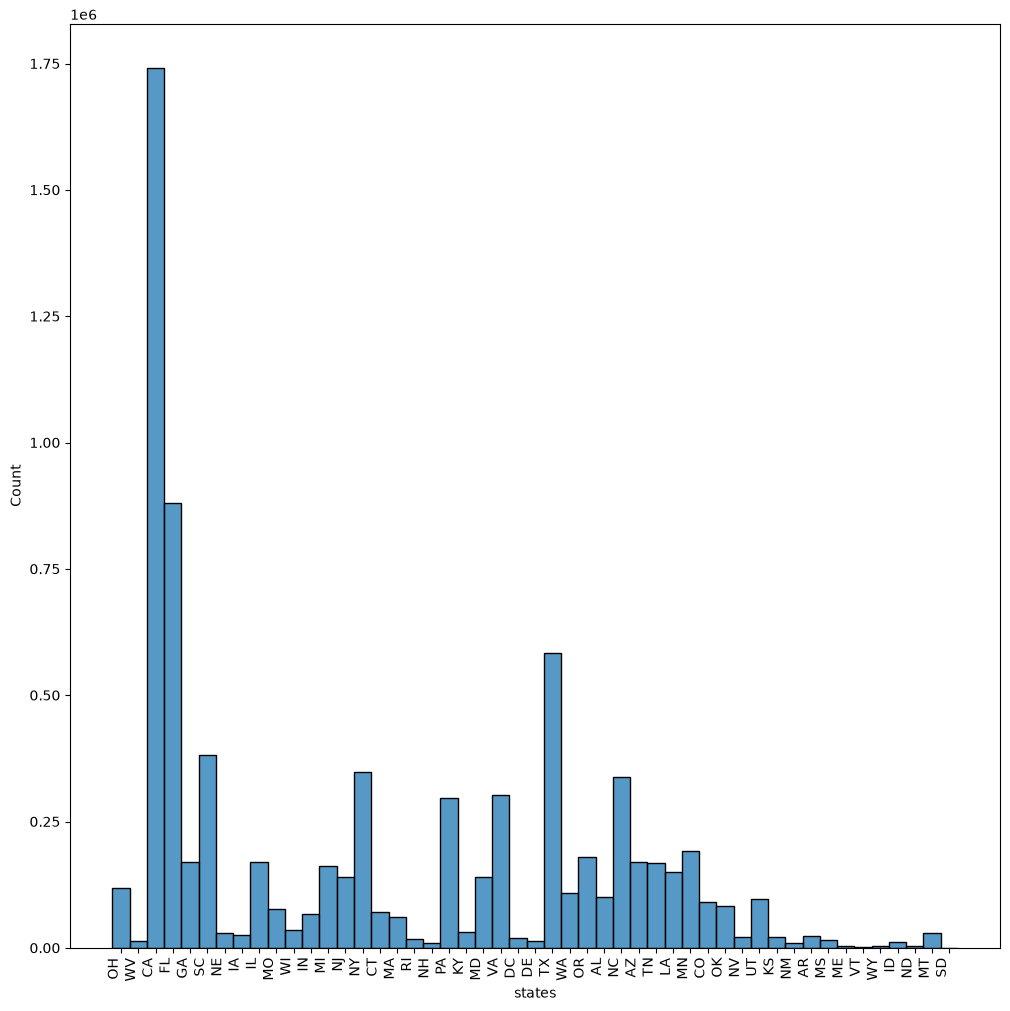

In [ ]:
plt.figure(figsize=(12,12))
sns.histplot(x = df_temp.state, bins = 49)
plt.xticks(rotation = 90, ha = 'right')
plt.xlabel('states')
plt.show()

### `city` and `county`

- Check whether city and county names repeat across states (`set` lists the distinct states per name).
- **Finding:** many names appear in several states, so they're ambiguous on their own and add no information beyond `state` and lat/lng.

In [ ]:
df_temp.groupby('county')['state'].apply(set)
df_temp.groupby('city')['state'].apply(set)

city
Aaronsburg                  {PA}
Abbeville       {LA, MS, SC, AL}
Abbotsford                  {WI}
Abbott                      {TX}
Abbottstown                 {PA}
                      ...       
Zortman                     {MT}
Zumbro Falls                {MN}
Zumbrota                    {MN}
Zuni                        {VA}
Zwingle                     {IA}
Name: state, Length: 13678, dtype: object

**Decision:** drop `city` and `county` — `state` and lat/lng already cover location at the coarse and precise levels.

In [ ]:
df_temp.drop(columns=['county','city'], inplace = True)

### `zipcode` and `street`

- Count unique zipcodes and streets.
- To do: look at 20 random zipcodes to spot the formats; look at 30 street names to spot road-type patterns.
- To do: cross-check `airport_code` against weather missingness — weather readings are copied from the nearest airport station.

In [ ]:
df_temp.zipcode.nunique()
df_temp.street.nunique()

336306

In [ ]:
df_temp.drop(columns=['zipcode'], inplace = True)

### Road type from `street`

- Define `street_type_shift`: extract the road type from the street name.
- Regex scans for road-type prefixes and suffixes anywhere in the text.
- A dictionary standardises the abbreviations; unmatched rows become 'Local/Other'.
- `.str.title()` makes the matches line up with the dictionary keys (e.g. 'st' → 'St').

In [ ]:
import re

def street_type_shift(df_temp, column_name='street'):

    pattern = r'(^I-|^US-|St|Ave|Blvd|Rd|Hwy|Avenue|Highway|Road|Pkwy|Ln|Dr)'
    
    raw_extracted = df_temp[column_name].str.extract(pattern, expand=False, flags=re.IGNORECASE)
    
    standard_map = {
        'I-': 'Interstate',
        'US-': 'US Highway',
        'St': 'Street', 'Avenue': 'Street',
        'Ave': 'Avenue', 'Avenue': 'Avenue',
        'Blvd': 'Boulevard',
        'Rd': 'Road', 'Road': 'Road',
        'Hwy': 'Highway', 'Highway': 'Highway',
        'Pkwy': 'Parkway',
        'Ln': 'Lane',
        'Dr': 'Drive'
    }
    
    df_temp['street_Type'] = raw_extracted.str.title().map(standard_map).fillna('Local/Other')
    
    return df_temp[column_name]

In [ ]:
df_temp['street_type'] = street_type_shift(df_temp)
df_temp.street_type.value_counts()

KeyError: 'Street'

## 8. Severity (target)

View the distribution of the target.

In [ ]:
sns.barplot(df_temp.severity, bins = 4)
plt.show()

## Checkpoint

- Checkpoint: save `df_temp` to parquet.

In [ ]:
df_temp.to_parquet('../data/df_temp.parquet', index = True)

## Next steps
- Steps 2–3: which column captures severity in terms of traffic effect and delay?
- Define the train/test split, the target, and the feature columns.
- Step 2: trends and basic analysis — correlations, covariance, scaling, standardisation, and plotting features against each other.